# Teste de Baseline com rede neural artificial para predição de resistência à compressão

In [22]:
%%capture
!pip install optuna

In [23]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GroupKFold
import matplotlib.pyplot as plt
from google.colab import drive
from tqdm.notebook import tqdm
from scipy import stats
import seaborn as sns
import pandas as pd
import numpy as np
import os, optuna

In [24]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
dirpath = '/content/drive/MyDrive/supervised-learning-studies/projeto/resistencia'

# Regressão neural
rna_file = 'df_resistencia_MLP.pkl'
rna_path = os.path.join(dirpath, rna_file)

df_rna = pd.read_pickle(rna_path)
df_rna['target'] = df_rna['Resistencia_Compressao_MPa'].copy()
df_rna.drop(inplace=True, columns=['Resistencia_Compressao_MPa'])

In [26]:
n_groups = df_rna['Autores/ano'].nunique()
print(f"Número de grupos únicos (Autores/ano): {n_groups}")
gkf = GroupKFold(n_splits=n_groups)

Número de grupos únicos (Autores/ano): 9


In [27]:
X = df_rna.drop(
    columns=["target", "Autores/ano"]
)

y = df_rna["target"]
groups = df_rna["Autores/ano"]

def objective(trial):
    rmse_scores = []
    n_layers = trial.suggest_int('n_layers', 2, 3)

    layer1 = trial.suggest_int('layer1', 20, 80)

    layer2 = trial.suggest_int(
        'layer2',
        5,
        layer1
    )

    if n_layers == 2:
        hidden_layer_sizes = (
            layer1,
            layer2
        )
    else:
        layer3 = trial.suggest_int(
            'layer3',
            3,
            layer2
        )

        hidden_layer_sizes = (
            layer1,
            layer2,
            layer3
        )

    hyperparams = {
        'hidden_layer_sizes': hidden_layer_sizes,
        'activation': 'tanh',
        'solver': 'lbfgs',
        'alpha': trial.suggest_float(
            'alpha',
            350,
            650,
            log=True
        ),
        'max_iter': 9000,
        'random_state': 42
    }

    for fold, (train_idx, val_idx) in enumerate(
        gkf.split(X, y, groups)
    ):

        X_train = X.iloc[train_idx]
        X_val = X.iloc[val_idx]

        y_train = y.iloc[train_idx]
        y_val = y.iloc[val_idx]

        scaler = StandardScaler()

        X_train = scaler.fit_transform(X_train)
        X_val = scaler.transform(X_val)

        model = MLPRegressor(**hyperparams)

        model.fit(X_train, y_train)

        preds = model.predict(X_val)

        rmse = root_mean_squared_error(y_val, preds)
        rmse_scores.append(rmse)

    return np.mean(rmse_scores)


# ==========================================
# EXECUTANDO O ESTUDO
# ==========================================
n_trials = 250

pbar = tqdm(total=n_trials, desc="Otimizando Hiperparâmetros", unit="trial")

def tqdm_callback(study, trial):
    pbar.update(1)
    pbar.set_postfix({
        "best_rmse": f"{study.best_value:.4f}"
    })

study_rna = optuna.create_study(
    direction="minimize",
    study_name="Tuning_Concreto"
)

study_rna.optimize(
    objective,
    n_trials=n_trials,
    callbacks=[tqdm_callback]
)

pbar.close()

print(f"Melhor RMSE alcançado (Cross-Validation): {study_rna.best_value:.4f}")
print("Melhores Hiperparâmetros encontrados:")
for key, value in study_rna.best_params.items():
    print(f"  '{key}': {value},")

In [37]:
best_params = {
    'hidden_layer_sizes': (31, 30, 27),
    'activation': "tanh",
    'solver': "lbfgs",
    'alpha': 354.0221869364922,
    'max_iter': 9000,
    'random_state': 42
}

In [38]:
all_preds = []
all_true = []
all_groups = []

X = df_rna.drop(
    columns=["target", "Autores/ano"]
)

y = df_rna["target"]
groups = df_rna["Autores/ano"]

for fold, (train_idx, val_idx) in enumerate(
    gkf.split(X, y, groups)
):

    X_train = X.iloc[train_idx]
    X_val = X.iloc[val_idx]

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)

    model = MLPRegressor(**best_params)

    model.fit(X_train, y_train)

    preds = model.predict(X_val)

    all_preds.extend(preds)
    all_true.extend(y_val)
    all_groups.extend(groups.iloc[val_idx])

In [39]:
lr_results = pd.DataFrame({
    "y_true": all_true,
    "y_pred": all_preds,
    "group": all_groups
})

lr_results["residual"] = (
    lr_results["y_true"] -
    lr_results["y_pred"]
)

lr_results["abs_error"] = (
    lr_results["residual"].abs()
)

## Observado vs Predito

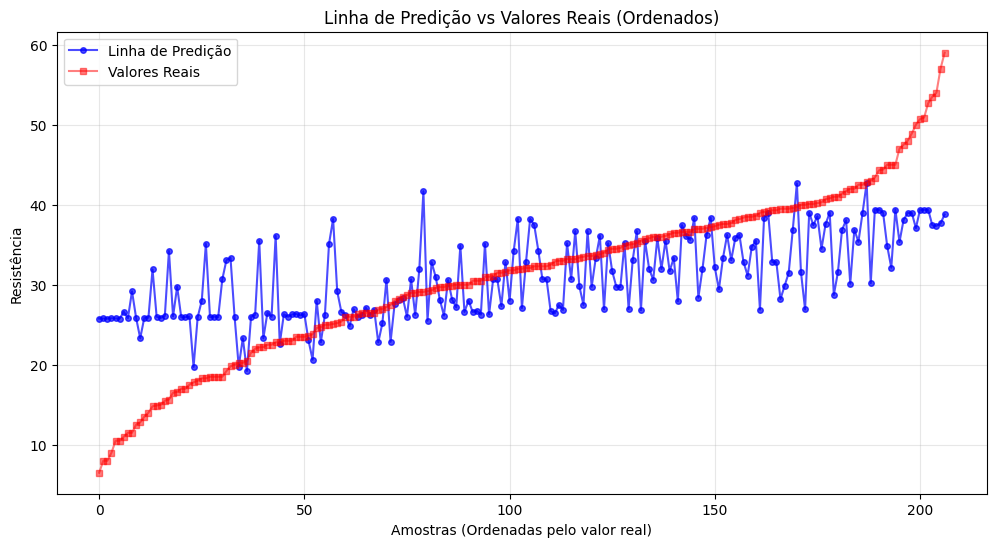

In [40]:
# Ordenando pelo valor real para a linha de predição não virar um "zigue-zague"
debug_df = lr_results.sort_values(by="y_true").reset_index(drop=True)
indices = range(len(debug_df))

plt.figure(figsize=(12, 6))

# 1. Linha das Predições (conectando os pontos preditos)
plt.plot(indices, debug_df["y_pred"], color='blue', label="Linha de Predição",
         alpha=0.7, linewidth=1.5, marker='o', markersize=4)

# 2. Pontos dos Valores Reais (Ground Truth)
plt.plot(indices, debug_df["y_true"], color='red', label="Valores Reais",
            alpha=0.5, linewidth=1.5, marker='s', markersize=4)

plt.title("Linha de Predição vs Valores Reais (Ordenados)")
plt.xlabel("Amostras (Ordenadas pelo valor real)")
plt.ylabel("Resistência")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Distribuição dos residuos

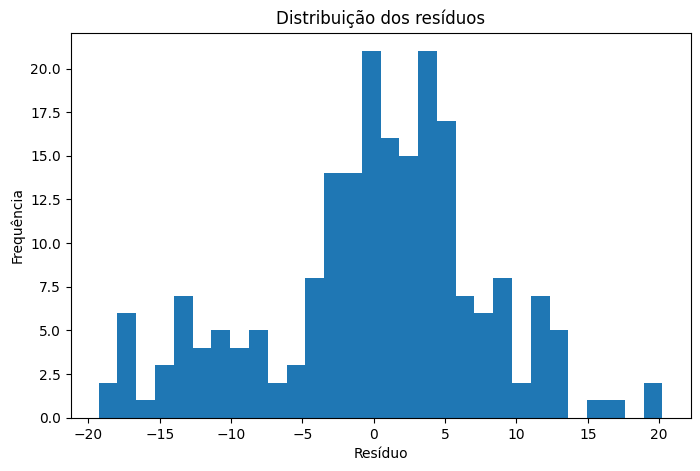

In [41]:
plt.figure(figsize=(8,5))

plt.hist(
    lr_results["residual"],
    bins=30
)

plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Distribuição dos resíduos")
plt.show()

## Residuo vs Predito

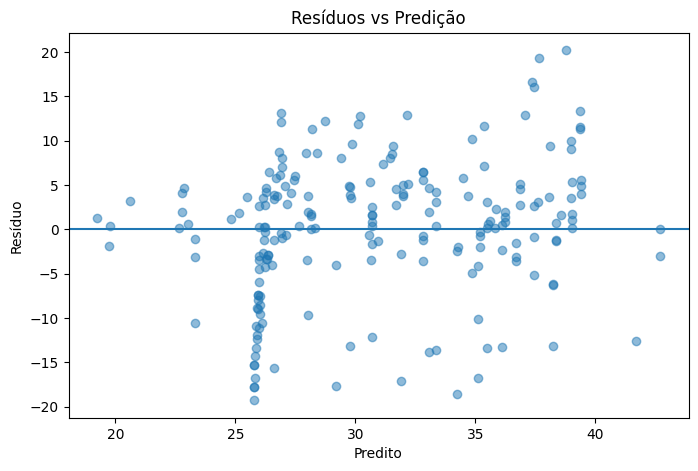

In [42]:
plt.figure(figsize=(8,5))

plt.scatter(
    lr_results["y_pred"],
    lr_results["residual"],
    alpha=0.5
)

plt.axhline(0)

plt.xlabel("Predito")
plt.ylabel("Resíduo")
plt.title("Resíduos vs Predição")
plt.show()

## Erro Medio por grupo

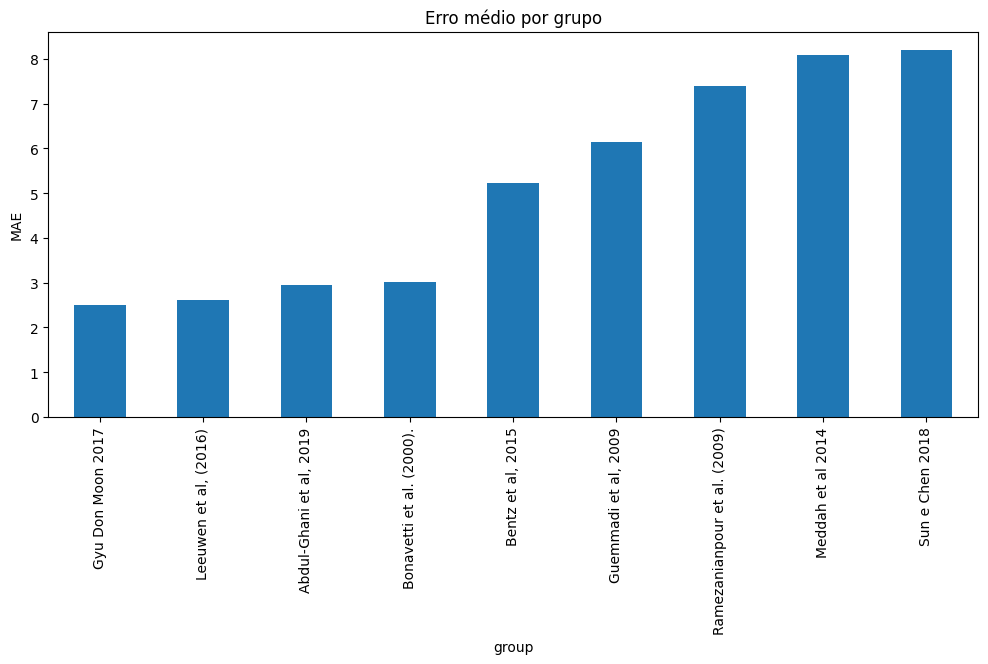

In [43]:
group_errors = (
    lr_results
    .groupby("group")
    ["abs_error"]
    .mean()
    .sort_values()
)
plt.figure(figsize=(12,5))

group_errors.plot(kind="bar")

plt.ylabel("MAE")
plt.title("Erro médio por grupo")
plt.show()

In [44]:
r2 = r2_score(debug_df["y_true"], debug_df["y_pred"])
rmse = root_mean_squared_error(debug_df["y_true"], debug_df["y_pred"])
mae = mean_absolute_error(debug_df["y_true"], debug_df["y_pred"])
mape = mean_absolute_percentage_error(debug_df["y_true"], debug_df["y_pred"])

print(f"root_mean_squared_error: {rmse:.4f}")
print(f"mean_absolute_error: {mae:.4f}")
print(f"mean_absolute_percentage_error: {mape:.4f}")
print(f"R² Score: {(r2*100):.4f}")

root_mean_squared_error: 7.7323
mean_absolute_error: 5.8942
mean_absolute_percentage_error: 0.2682
R² Score: 42.5164
